# Evaluation Analysis for Recommender Output

In this section we will analyze and compare the generated recommendations and predictions from a predefined list of algorithms with the goal of assessing the performance of each algorithm with respect to a metric. In other words, we would rank the algorithms for each metric considered with respect to performance.

## Setup

Below are the list of packages required to successfully run the analysis. They are divided into partitions to signify their specific task.<br>
We need the pathlib package for working with files and folders

In [1]:
from pathlib import Path
import json

Load libraries for analysis and visualization:

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Import the LensKit metrics for analysis:

In [3]:
from lenskit.data import Dataset, ItemListCollection
from lenskit.metrics import RunAnalysis, RMSE, NDCG, RecipRank, RBP

## Load Data

The recommendations are in `runs`, and we will need to reassemble the test data from `test`.

In [4]:
dataset = "ml-100k"

In [5]:
# Parameters
dataset = "ml-100k"


In [6]:
output_root = Path("runs")
run_dir = output_root / dataset

In [7]:
dirs = [rd for rd in run_dir.iterdir() if rd.is_dir()]

In [8]:
recs = ItemListCollection(['model', 'user_id'], index=False)
for fld in dirs:
    for file in fld.glob("recs-*"):
        rec = ItemListCollection.load_parquet(file)
        recs.add_from(rec, model=fld.name)

In [9]:
rec_algos = sorted(set(a for (a, _u) in recs.keys()))
rec_algos

['als-explicit',
 'als-implicit',
 'bias',
 'flex-bpr',
 'flex-explicit',
 'flex-logistic',
 'flex-warp',
 'iknn-explicit',
 'iknn-implicit',
 'lightgcn',
 'lightgcn-warp',
 'popular',
 'uknn-explicit',
 'uknn-implicit']

In [10]:
preds = ItemListCollection(['model', 'user_id'], index=False)
for fld in dirs:
    for file in fld.glob("pred-*"):
        pred = ItemListCollection.load_parquet(file)
        preds.add_from(pred, model=fld.name)

We need to load the test data so that we have the ground truths for computing accuracy.

In [11]:
test = ItemListCollection.load_parquet(f"data-split/{dataset}/test.parquet")

## Top-N Metrics

`RunListAnalysis` computes metrics for recommendation results and takes care of
matching recommendations and ground truth.

In [12]:
ra = RunAnalysis()

ra.add_metric(NDCG())
ra.add_metric(RecipRank())
ra.add_metric(RBP())

rec_results = ra.compute(recs, test)
rec_results.list_summary('model')

/home/mde48/lenskit/lkpy/src/lenskit/metrics/bulk.py:92: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df = scores.groupby(list(keys)).agg(["mean", "median", "std"]).stack(level=0)


mean    median       std
model                                                
als-explicit  NDCG       0.109883  0.074676  0.116535
              RBP        0.070930  0.001864  0.136573
              RecipRank  0.153483  0.035714  0.258624
als-implicit  NDCG       0.166018  0.133573  0.161304
              RBP        0.105256  0.014391  0.153530
              RecipRank  0.250572  0.058824  0.358533
bias          NDCG       0.107843  0.073623  0.115772
              RBP        0.074535  0.006072  0.119829
              RecipRank  0.142874  0.047619  0.222645
flex-bpr      NDCG       0.078768  0.060835  0.086766
              RBP        0.059763  0.000317  0.127920
              RecipRank  0.123821  0.025641  0.241348
flex-explicit NDCG       0.082081  0.061022  0.087998
              RBP        0.049576  0.000630  0.091961
              RecipRank  0.141056  0.028571  0.258404
flex-logistic NDCG       0.078059  0.053897  0.083618
              RBP        0.053030  0.000432  0.113018
              RecipRank  0.119343  0.027027  0.241021
flex-warp     NDCG       0.081694  0.053257  0.084621
              RBP        0.059115  0.000597  0.124332
              RecipRank  0.131732  0.028571  0.253859
iknn-explicit NDCG       0.077086  0.052108  0.086390
              RBP        0.039279  0.000597  0.086766
              RecipRank  0.100569  0.028571  0.207027
iknn-implicit NDCG       0.141490  0.056313  0.176940
              RBP        0.125543  0.000163  0.229975
              RecipRank  0.214282  0.023256  0.345810
lightgcn      NDCG       0.197738  0.152513  0.185620
              RBP        0.137257  0.041854  0.206624
              RecipRank  0.279748  0.111111  0.373470
lightgcn-warp NDCG       0.200962  0.158770  0.189896
              RBP        0.140290  0.040874  0.208499
              RecipRank  0.284131  0.100000  0.374062
popular       NDCG       0.194559  0.161316  0.179668
              RBP        0.131380  0.040874  0.191536
              RecipRank  0.262258  0.111111  0.340544
uknn-explicit NDCG       0.078296  0.066071  0.072330
              RBP        0.020274  0.000713  0.043821
              RecipRank  0.050235  0.029412  0.076343
uknn-implicit NDCG       0.183582  0.125354  0.195494
              RBP        0.128590  0.024907  0.208484
              RecipRank  0.266727  0.071429  0.368543

We can reshape the list metrics and plot them:

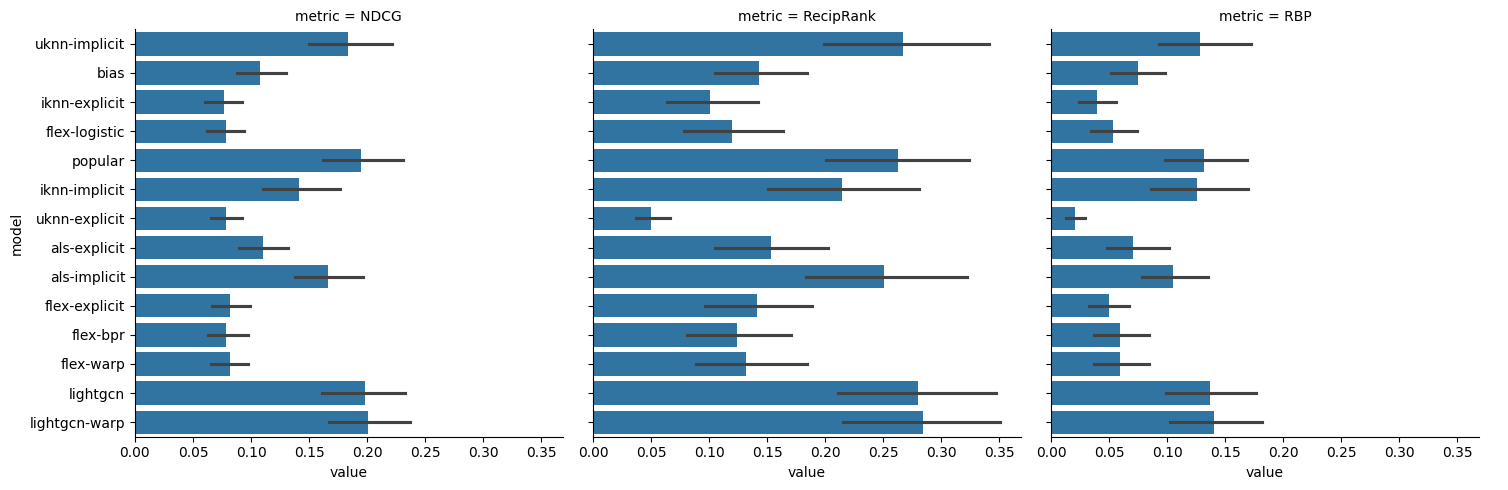

In [13]:
metrics = rec_results.list_metrics()
metrics = metrics.melt(var_name='metric', ignore_index=False).reset_index()
sns.catplot(metrics, y='model', x='value', col='metric', kind='bar')
plt.show()

## Prediction RMSE

We will also look at the prediction RMSE.

In [14]:
pa = RunAnalysis()

pa.add_metric(RMSE(missing_scores='ignore', missing_truth='ignore'))

pred_results = pa.compute(preds, test)
pred_results.list_summary('model')

/home/mde48/lenskit/lkpy/src/lenskit/metrics/bulk.py:92: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df = scores.groupby(list(keys)).agg(["mean", "median", "std"]).stack(level=0)


,,mean,median,std
model,,,,
als-explicit,RMSE,0.861863,0.843695,0.361162
bias,RMSE,0.875318,0.851510,0.353092
flex-explicit,RMSE,0.945196,0.921993,0.397228
iknn-explicit,RMSE,0.867329,0.860759,0.370899
uknn-explicit,RMSE,0.881776,0.863499,0.379490


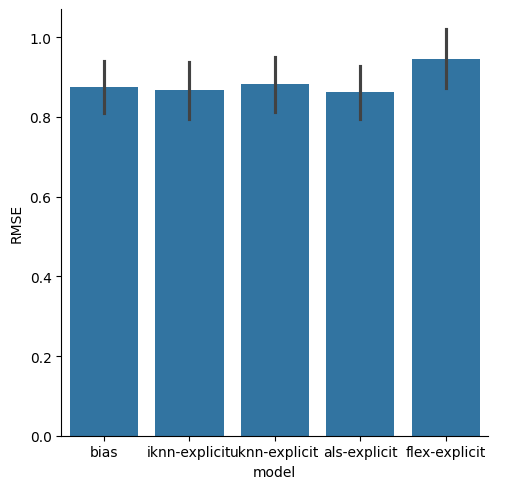

In [15]:
pred_metrics = pred_results.list_metrics().reset_index()
sns.catplot(pred_metrics, x='model', y='RMSE', kind='bar')
plt.show()

## Save Metrics

We'll now save the metrics to a file.

In [16]:
rlsum = rec_results.list_summary('model')['mean'].unstack()
rlsum

/home/mde48/lenskit/lkpy/src/lenskit/metrics/bulk.py:92: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df = scores.groupby(list(keys)).agg(["mean", "median", "std"]).stack(level=0)


,NDCG,RBP,RecipRank
model,,,
als-explicit,0.109883,0.070930,0.153483
als-implicit,0.166018,0.105256,0.250572
bias,0.107843,0.074535,0.142874
flex-bpr,0.078768,0.059763,0.123821
flex-explicit,0.082081,0.049576,0.141056
flex-logistic,0.078059,0.053030,0.119343
flex-warp,0.081694,0.059115,0.131732
iknn-explicit,0.077086,0.039279,0.100569
iknn-implicit,0.141490,0.125543,0.214282


In [17]:
rlsum.to_json(f'eval-metrics.{dataset}.json', orient='index')